# 📏 Étape 3 — Baseline Persistence

Avant d'entraîner des modèles complexes, on établit une **baseline** : le score minimum à battre.

La baseline **persistence** est le modèle le plus naïf possible :
> *« Le niveau dans 10 minutes sera le même qu'aujourd'hui. »*

$$\hat{y}(t + H) = y(t)$$

C'est un benchmark très pertinent pour les séries temporelles à forte autocorrélation (comme un niveau de réservoir qui évolue lentement).  
Si un modèle ML ne fait pas **au moins -20% de MAE/RMSE** par rapport à cette baseline, il n'apporte pas grand chose.

On calcule aussi une **baseline moyenne** (prédire toujours la moyenne du train) pour avoir un second point de référence.

## 1. Imports et chargement des données préprocessées

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

HORIZON = 10   # doit correspondre à ce qui a été utilisé dans le préprocessing
SAVE_DIR = 'preprocessed'

In [2]:
# Chargement des données tabulaires produites à l'étape 2
X_train = np.load(f'{SAVE_DIR}/X_train.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')   # valeurs réelles (non normalisées)
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

ts_train = pd.read_csv(f'{SAVE_DIR}/ts_train.csv', parse_dates=[0]).iloc[:, 0]
ts_test  = pd.read_csv(f'{SAVE_DIR}/ts_test.csv',  parse_dates=[0]).iloc[:, 0]

feature_cols = pd.read_csv(f'{SAVE_DIR}/feature_cols.csv').iloc[:, 0].tolist()

print(f"Train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"Test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"Nombre de features : {len(feature_cols)}")

Train : (5680, 366)  |  y_train : (5680,)
Test  : (1421, 366)   |  y_test  : (1421,)
Nombre de features : 366


## 2. Récupération de la valeur actuelle (t)

La baseline persistence prédit `y(t+H) = y(t)`.  
La valeur `y(t)` correspond à la colonne `1_LT_001_PV` dans les features (lag 0 = valeur actuelle).  
On l'extrait directement depuis `X_test`.

In [3]:
# Identifier l'index de la colonne TARGET dans les features
TARGET = '1_LT_001_PV'
target_idx = feature_cols.index(TARGET)
print(f"Index de '{TARGET}' dans les features : {target_idx}")

# Valeur actuelle sur le test (non normalisée — on a chargé y_test en valeur réelle)
# La valeur actuelle correspond à y_test décalé de +HORIZON (i.e. ce qu'on avait à t)
# On recharge le df_work pour récupérer la valeur de TARGET au bon timestamp
import pandas as pd
df_raw = pd.read_csv('WADI_14days_new.csv')
df_raw['datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], dayfirst=False, errors='coerce')
df_raw = df_raw.sort_values('datetime').set_index('datetime')
df_raw = df_raw.drop(columns=['Row','Date','Time'], errors='ignore')
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw = df_raw.resample('1min').mean().interpolate(method='linear', limit_direction='both')

# Valeur de TARGET aux timestamps du test
y_current = df_raw[TARGET].reindex(ts_test).values

print(f"y_current shape : {y_current.shape}")
print(f"y_test    shape : {y_test.shape}")

# Aligner les longueurs (quelques NaN possibles sur les bords)
mask = ~np.isnan(y_current) & ~np.isnan(y_test)
y_current = y_current[mask]
y_true    = y_test[mask]
ts_eval   = ts_test.values[mask]
print(f"Points d'évaluation valides : {mask.sum():,}")

Index de '1_LT_001_PV' dans les features : 0
y_current shape : (1421,)
y_test    shape : (1421,)
Points d'évaluation valides : 1,421


## 3. Calcul des métriques

On utilise trois métriques :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Erreur moyenne absolue (même unité que le niveau) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Pénalise plus les grosses erreurs |
| **Skill score** | $1 - \frac{RMSE_{model}}{RMSE_{persistence}}$ | % d'amélioration vs persistence (>0 = meilleur) |

Le **skill score** sera la référence principale pour comparer tous les modèles.

In [4]:
def compute_metrics(y_true, y_pred, label='Modèle', rmse_ref=None):
    """Calcule MAE, RMSE et Skill score vs une référence."""
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    skill = (1 - rmse / rmse_ref) * 100 if rmse_ref is not None else None

    print(f"{'─'*40}")
    print(f" {label}")
    print(f"{'─'*40}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    if skill is not None:
        sign = '+' if skill >= 0 else ''
        print(f"  Skill : {sign}{skill:.2f}% vs persistence")
    print()
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'Skill': skill}

results = []

## 4. Baseline Persistence

Prédiction : `ŷ(t+10) = y(t)` — on recopie simplement la valeur courante.

**Résultat attendu :** MAE et RMSE de référence. Ce sont les scores que tous les modèles suivants devront dépasser de -20% minimum.

In [5]:
y_pred_persistence = y_current

res_persistence = compute_metrics(y_true, y_pred_persistence, label=f'Persistence (t → t+{HORIZON})')
rmse_persistence = res_persistence['RMSE']
results.append(res_persistence)

print(f"⚠️  Seuil à battre (-20%) :")
print(f"   MAE  < {res_persistence['MAE'] * 0.8:.4f}")
print(f"   RMSE < {rmse_persistence * 0.8:.4f}")

────────────────────────────────────────
 Persistence (t → t+10)
────────────────────────────────────────
  MAE   : 0.0339
  RMSE  : 0.0467

⚠️  Seuil à battre (-20%) :
   MAE  < 0.0272
   RMSE < 0.0373


## 5. Baseline Moyenne

Prédiction : `ŷ = mean(y_train)` — on prédit toujours la même valeur (la moyenne de l'entraînement).  
C'est une baseline encore plus basique, utile pour vérifier que persistence est bien supérieure.

In [6]:
y_pred_mean = np.full_like(y_true, fill_value=np.mean(y_train))

res_mean = compute_metrics(y_true, y_pred_mean,
                           label='Moyenne train (naive)',
                           rmse_ref=rmse_persistence)
results.append(res_mean)

────────────────────────────────────────
 Moyenne train (naive)
────────────────────────────────────────
  MAE   : 2.5341
  RMSE  : 2.6669
  Skill : -5614.82% vs persistence



## 6. Persistence sur plusieurs horizons

On évalue la baseline pour plusieurs horizons (5, 10, 30 min) pour comprendre à quel point l'erreur croît avec le temps.  
Cela permet aussi de calibrer l'ambition des modèles selon l'horizon choisi.

**Résultat attendu :** courbe RMSE vs horizon — montre la difficulté croissante de la prédiction.

Horizon  1 min → MAE = 0.0035  |  RMSE = 0.0059
Horizon  5 min → MAE = 0.0175  |  RMSE = 0.0293
Horizon 10 min → MAE = 0.0347  |  RMSE = 0.0580
Horizon 15 min → MAE = 0.0517  |  RMSE = 0.0860
Horizon 20 min → MAE = 0.0685  |  RMSE = 0.1134
Horizon 30 min → MAE = 0.1013  |  RMSE = 0.1660


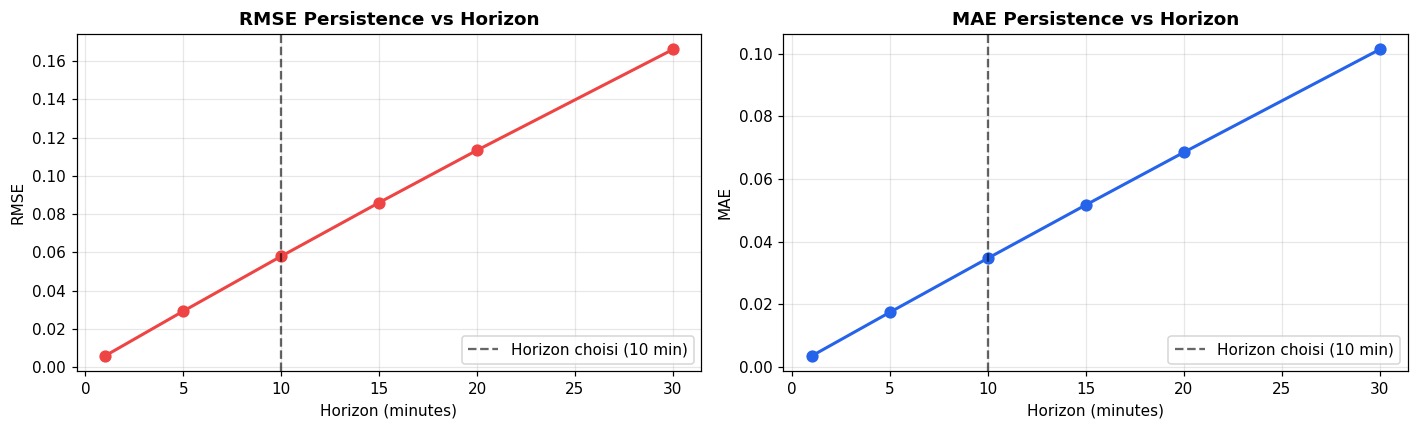

In [7]:
horizons = [1, 5, 10, 15, 20, 30]
horizon_rmse = []
horizon_mae  = []

target_series = df_raw[TARGET].dropna()

for h in horizons:
    # Pour chaque horizon, y(t) prédit y(t+h)
    y_now  = target_series.values[:-h]
    y_fut  = target_series.values[h:]
    mae_h  = np.mean(np.abs(y_fut - y_now))
    rmse_h = np.sqrt(np.mean((y_fut - y_now) ** 2))
    horizon_rmse.append(rmse_h)
    horizon_mae.append(mae_h)
    print(f"Horizon {h:>2} min → MAE = {mae_h:.4f}  |  RMSE = {rmse_h:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(horizons, horizon_rmse, 'o-', color='#EF4444', linewidth=2, markersize=7)
axes[0].axvline(HORIZON, color='black', linestyle='--', alpha=0.6, label=f'Horizon choisi ({HORIZON} min)')
axes[0].set_xlabel('Horizon (minutes)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Persistence vs Horizon', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(horizons, horizon_mae, 'o-', color='#2563EB', linewidth=2, markersize=7)
axes[1].axvline(HORIZON, color='black', linestyle='--', alpha=0.6, label=f'Horizon choisi ({HORIZON} min)')
axes[1].set_xlabel('Horizon (minutes)')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Persistence vs Horizon', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualisation des prédictions

On visualise la prédiction persistence vs la vérité sur un extrait du test pour comprendre visuellement où elle se trompe.  
La persistence a tendance à rater les **changements brusques** (activations de pompes, ouvertures de vannes).

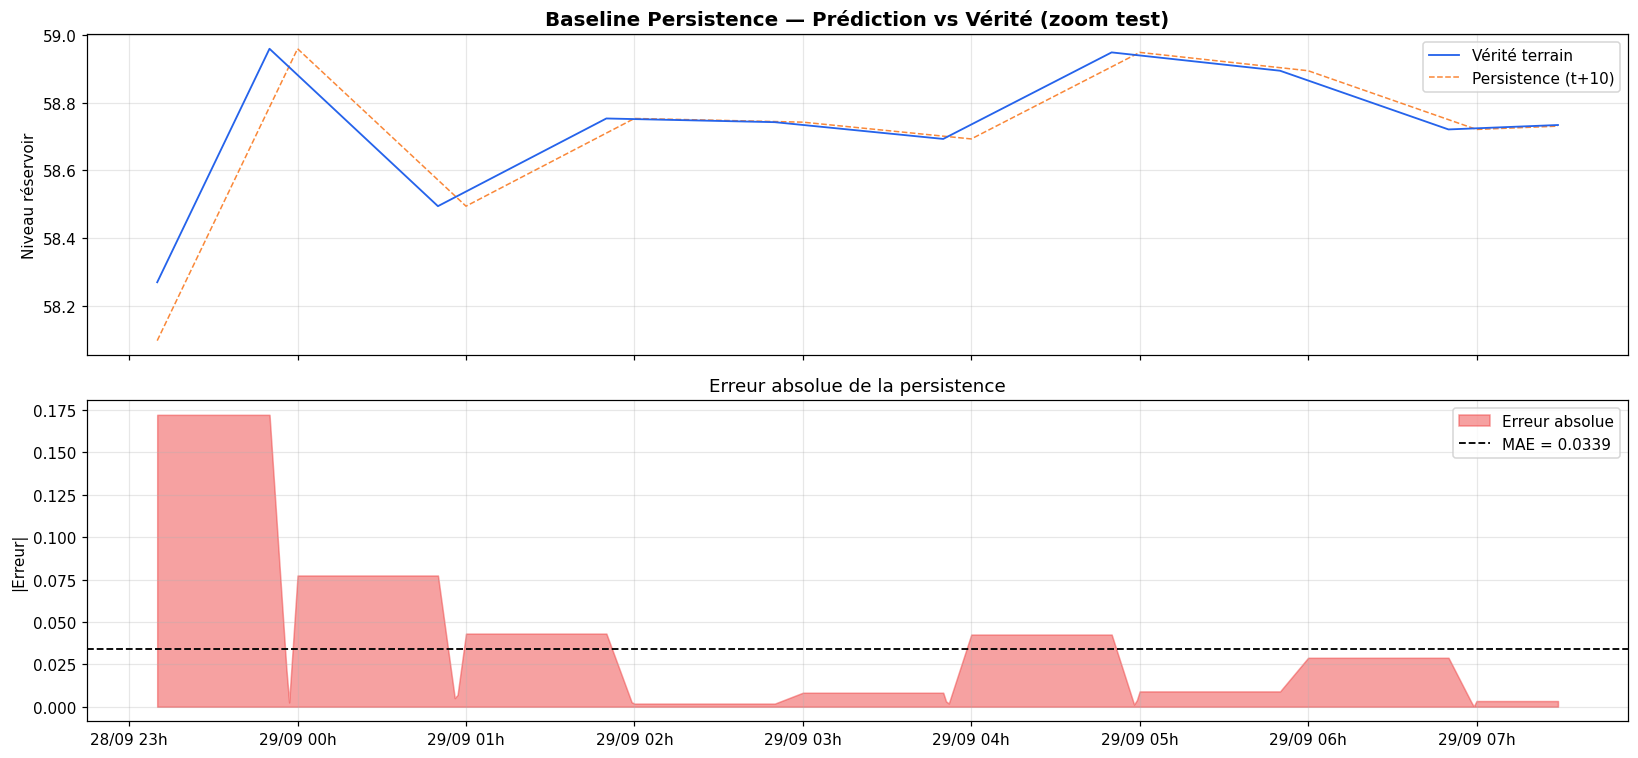

In [8]:
# Zoom sur 500 points du test pour lisibilité
N_PLOT = 500
ts_plot = pd.to_datetime(ts_eval[:N_PLOT])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# ── Subplot 1 : prédiction vs vérité ─────────────────────────────────────────
axes[0].plot(ts_plot, y_true[:N_PLOT],              color='#2563EB', linewidth=1.2,
             label='Vérité terrain', zorder=3)
axes[0].plot(ts_plot, y_pred_persistence[:N_PLOT],  color='#F97316', linewidth=1,
             linestyle='--', label=f'Persistence (t+{HORIZON})', alpha=0.85)
axes[0].set_ylabel('Niveau réservoir')
axes[0].set_title('Baseline Persistence — Prédiction vs Vérité (zoom test)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Subplot 2 : erreur absolue ────────────────────────────────────────────────
error = np.abs(y_true[:N_PLOT] - y_pred_persistence[:N_PLOT])
axes[1].fill_between(ts_plot, error, color='#EF4444', alpha=0.5, label='Erreur absolue')
axes[1].axhline(res_persistence['MAE'], color='black', linestyle='--',
                linewidth=1.2, label=f"MAE = {res_persistence['MAE']:.4f}")
axes[1].set_ylabel('|Erreur|')
axes[1].set_xlabel('')
axes[1].set_title('Erreur absolue de la persistence', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))

plt.tight_layout()
plt.show()

## 8. Autocorrélation de la cible

L'autocorrélation mesure à quel point `y(t)` est corrélé avec `y(t-k)` pour différents décalages `k`.  
Une autocorrélation élevée à k=10 explique pourquoi la persistence est une baseline difficile à battre — et indique combien de lags il faut inclure dans les modèles ML.

**Résultat attendu :** voir jusqu'à quel lag l'autocorrélation reste significative.

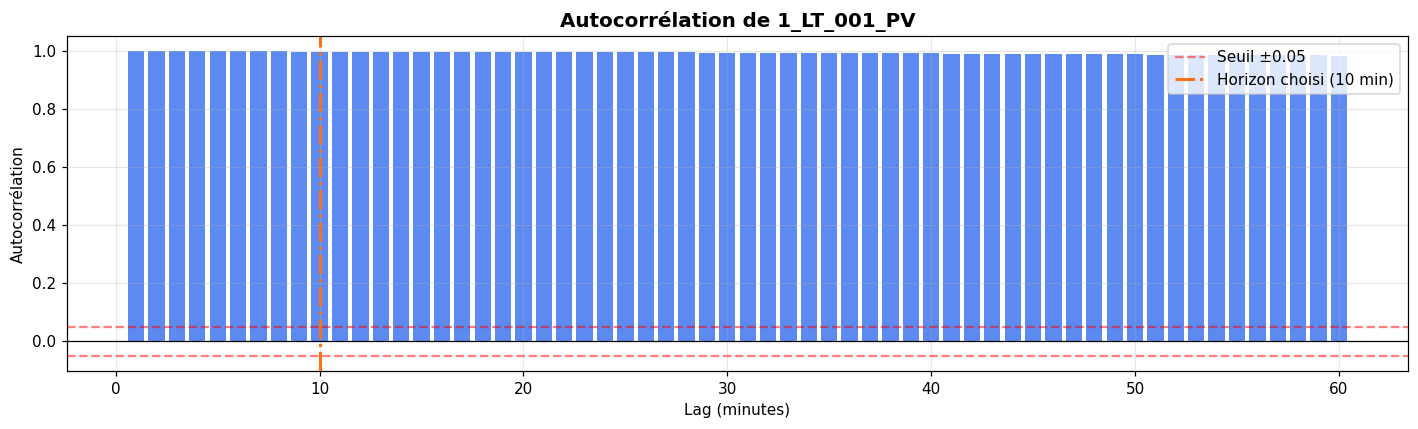

Autocorrélation à lag 10 (= horizon) : 0.9995
Autocorrélation à lag 1                    : 1.0000
Autocorrélation à lag 30                   : 0.9957


In [9]:
from pandas.plotting import autocorrelation_plot

target_series_clean = df_raw[TARGET].dropna()

# Calcul manuel des autocorrélations jusqu'à 60 lags
max_lag = 60
lags_range = range(1, max_lag + 1)
autocorrs = [target_series_clean.autocorr(lag=k) for k in lags_range]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(list(lags_range), autocorrs, color='#2563EB', alpha=0.75, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.05,  color='red', linestyle='--', alpha=0.5, label='Seuil ±0.05')
ax.axhline(-0.05, color='red', linestyle='--', alpha=0.5)
ax.axvline(HORIZON, color='#F97316', linewidth=2, linestyle='-.',
           label=f'Horizon choisi ({HORIZON} min)')
ax.set_xlabel('Lag (minutes)')
ax.set_ylabel('Autocorrélation')
ax.set_title('Autocorrélation de 1_LT_001_PV', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Autocorrélation à lag {HORIZON} (= horizon) : {autocorrs[HORIZON-1]:.4f}")
print(f"Autocorrélation à lag 1                    : {autocorrs[0]:.4f}")
print(f"Autocorrélation à lag 30                   : {autocorrs[29]:.4f}")

## 9. Tableau de bord des baselines

On récapitule tous les scores dans un tableau propre et on sauvegarde les résultats pour les comparer avec les modèles ML/DL.

In [10]:
import os

df_results = pd.DataFrame(results)[['label', 'MAE', 'RMSE', 'Skill']]
df_results = df_results.round(4)
df_results.columns = ['Modèle', 'MAE', 'RMSE', 'Skill (%)']
print("=" * 55)
print(" TABLEAU DE BORD — BASELINES")
print("=" * 55)
print(df_results.to_string(index=False))
print("=" * 55)
print(f"\n🎯 Objectif modèles ML/DL :")
print(f"   MAE  < {res_persistence['MAE'] * 0.8:.4f}   (−20% vs persistence)")
print(f"   RMSE < {rmse_persistence * 0.8:.4f}   (−20% vs persistence)")
print(f"   Skill > 20%")

# Sauvegarde pour comparaison future
os.makedirs(SAVE_DIR, exist_ok=True)
df_results.to_csv(f'{SAVE_DIR}/resultats_baselines.csv', index=False)

# Sauvegarde du RMSE de persistence (référence pour le skill score)
np.save(f'{SAVE_DIR}/rmse_persistence.npy', np.array([rmse_persistence]))
np.save(f'{SAVE_DIR}/mae_persistence.npy',  np.array([res_persistence['MAE']]))

print(f"\n✅ Résultats sauvegardés dans '{SAVE_DIR}/resultats_baselines.csv'")
print("→ Prochaine étape : modeles_ml.ipynb (XGBoost / Random Forest)")

 TABLEAU DE BORD — BASELINES
                Modèle    MAE   RMSE  Skill (%)
Persistence (t → t+10) 0.0339 0.0467        NaN
 Moyenne train (naive) 2.5341 2.6669 -5614.8227

🎯 Objectif modèles ML/DL :
   MAE  < 0.0272   (−20% vs persistence)
   RMSE < 0.0373   (−20% vs persistence)
   Skill > 20%

✅ Résultats sauvegardés dans 'preprocessed/resultats_baselines.csv'
→ Prochaine étape : modeles_ml.ipynb (XGBoost / Random Forest)
